# Phase 2 - Hypothesis Testing

Phân tích xác nhận trên toàn bộ 395 quan sát. Các kiểm định đều hai phía. So sánh hai nhóm dùng Welch t-test để ước lượng khác biệt trung bình; Shapiro-Wilk và Levene chỉ là diagnostics, không dùng làm pre-test để tự động đổi phương pháp. P-value của 10 kiểm định chính được hiệu chỉnh Holm.

H9 (`absences`) là giả thuyết exploratory/post-hoc vì được hình thành sau EDA.

## 0. Setup và dữ liệu

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
ALPHA = 0.05
ROOT = Path("..").resolve()
DATA_RAW = ROOT / "data" / "raw"
DATA_OUT = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "report" / "figures"
DATA_OUT.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})
pd.set_option("display.max_columns", 50)

def display_table(data, caption=None, precision=3):
    """Hiển thị DataFrame với đường viền rõ, dùng được trực tiếp trong Jupyter."""
    if isinstance(data, pd.Series):
        data = data.rename("value").to_frame()
    styler = (
        data.style
        .format(precision=precision, na_rep="-")
        .set_caption(caption or "")
        .set_table_styles([
            {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%")]},
            {"selector": "th", "props": [("border", "1px solid #777"), ("padding", "6px"),
                                           ("background-color", "#e9eef5"), ("text-align", "center")]},
            {"selector": "td", "props": [("border", "1px solid #999"), ("padding", "6px")]},
            {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold"),
                                                ("font-size", "1.05em"), ("padding", "6px")]},
            {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#f7f9fc")]},
        ])
    )
    display(styler)

print(f"Project root: {ROOT}")
from itertools import combinations
from statsmodels.stats.multitest import multipletests

df = pd.read_csv(DATA_OUT / "student_mat_clean.csv")
assert len(df) == 395, "Phase 2 phải dùng đủ 395 quan sát"
print(f"Shape: {df.shape}")

Project root: C:\Users\LENOVO\Downloads\khu lap trinh\student-performance-project
Shape: (395, 33)


## 1. Hàm hỗ trợ

In [2]:
def hedges_g(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    nx, ny = len(x), len(y)
    pooled = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    d = (x.mean() - y.mean()) / pooled
    correction = 1 - 3 / (4 * (nx + ny) - 9)
    return d * correction

def epsilon_squared(h, k, n):
    return max(0.0, (h - k + 1) / (n - k))

def two_group_test(label, variable, level_a, level_b, note=""):
    x = df.loc[df[variable] == level_a, "G3"].to_numpy()
    y = df.loc[df[variable] == level_b, "G3"].to_numpy()
    t, p = stats.ttest_ind(x, y, equal_var=False)
    lev, p_lev = stats.levene(x, y, center="median")
    return {
        "hypothesis": label, "contrast": f"{level_a} - {level_b}", "test": "Welch t-test",
        "statistic": t, "p_raw": p, "effect": "Hedges g", "effect_value": hedges_g(x, y),
        "estimate": x.mean() - y.mean(), "n": len(x) + len(y), "diagnostic": f"Levene p={p_lev:.3g}",
        "note": note,
    }

def kruskal_test(label, variable, note=""):
    groups = [g["G3"].to_numpy() for _, g in df.groupby(variable, sort=True)]
    h, p = stats.kruskal(*groups)
    return {
        "hypothesis": label, "contrast": "omnibus", "test": "Kruskal-Wallis", "statistic": h,
        "p_raw": p, "effect": "epsilon^2", "effect_value": epsilon_squared(h, len(groups), len(df)),
        "estimate": np.nan, "n": len(df), "diagnostic": "ordinal groups", "note": note,
    }

def spearman_test(label, variable, note=""):
    rho, p = stats.spearmanr(df[variable], df["G3"])
    return {
        "hypothesis": label, "contrast": f"{variable} vs G3", "test": "Spearman", "statistic": rho,
        "p_raw": p, "effect": "rho", "effect_value": rho, "estimate": rho, "n": len(df),
        "diagnostic": "ordinal/rank association", "note": note,
    }

def dunn_posthoc(data, group_col, value_col="G3"):
    work = data[[group_col, value_col]].dropna().copy()
    work["rank"] = stats.rankdata(work[value_col])
    n = len(work)
    tie_counts = work[value_col].value_counts().to_numpy()
    tie_correction = 1 - np.sum(tie_counts**3 - tie_counts) / (n**3 - n)
    rank_means = work.groupby(group_col)["rank"].mean()
    sizes = work.groupby(group_col).size()
    variance = n * (n + 1) / 12 * tie_correction
    rows = []
    for a, b in combinations(rank_means.index, 2):
        se = np.sqrt(variance * (1 / sizes[a] + 1 / sizes[b]))
        z = (rank_means[a] - rank_means[b]) / se
        rows.append({"variable": group_col, "group_a": a, "group_b": b, "z": z,
                     "p_raw": 2 * stats.norm.sf(abs(z))})
    result = pd.DataFrame(rows)
    result["p_holm"] = multipletests(result["p_raw"], method="holm")[1]
    return result

def annotate(ax, text):
    ax.text(.02, .98, text, transform=ax.transAxes, ha="left", va="top", fontsize=9,
            bbox={"boxstyle": "round", "facecolor": "white", "alpha": .85})

## 2. Chạy 10 kiểm định chính

In [3]:
results = [
    two_group_test("H1: sex", "sex", "M", "F"),
    two_group_test("H2: address", "address", "U", "R"),
    two_group_test("H3: famsup", "famsup", "yes", "no", note="observational; confounding possible"),
    kruskal_test("H4: studytime", "studytime"),
    spearman_test("H5: Walc", "Walc"),
    two_group_test("H6: higher", "higher", "yes", "no"),
    kruskal_test("H7: failures", "failures"),
    kruskal_test("H8a: Medu", "Medu"),
    kruskal_test("H8b: Fedu", "Fedu"),
    spearman_test("H9: absences", "absences", note="post-hoc/exploratory"),
]
summary = pd.DataFrame(results)
summary["p_holm"] = multipletests(summary["p_raw"], method="holm")[1]
summary["significant_holm"] = summary["p_holm"] < ALPHA
summary = summary[["hypothesis", "contrast", "test", "statistic", "p_raw", "p_holm",
                   "effect", "effect_value", "estimate", "n", "diagnostic", "note", "significant_holm"]]
display(summary, "Kết quả kiểm định chính và Holm correction", precision=4)
with (DATA_OUT / "hypothesis_test_results.csv").open("w", encoding="utf-8", newline="") as handle:
    summary.to_csv(handle, index=False, lineterminator=chr(10))

,hypothesis,contrast,test,statistic,p_raw,p_holm,effect,effect_value,estimate,n,diagnostic,note,significant_holm
0,H1: sex,M - F,Welch t-test,2.065057,3.957700e-02,2.196829e-01,Hedges g,0.207397,0.948092,395,Levene p=0.794,,False
1,H2: address,U - R,Welch t-test,2.110137,3.661381e-02,2.196829e-01,Hedges g,0.254450,1.162903,395,Levene p=0.843,,False
2,H3: famsup,yes - no,Welch t-test,-0.773580,4.397524e-01,8.795049e-01,Hedges g,-0.080086,-0.367796,395,Levene p=0.989,observational; confounding possible,False
3,H4: studytime,omnibus,Kruskal-Wallis,7.578856,5.556654e-02,2.196829e-01,epsilon^2,0.011711,NaN,395,ordinal groups,,False
4,H5: Walc,Walc vs G3,Spearman,-0.104459,3.797038e-02,2.196829e-01,rho,-0.104459,-0.104459,395,ordinal/rank association,,False
5,H6: higher,yes - no,Welch t-test,3.447378,2.440034e-03,1.952027e-02,Hedges g,0.842685,3.808000,395,Levene p=0.593,,True
6,H7: failures,omnibus,Kruskal-Wallis,53.115070,1.732667e-11,1.732667e-10,epsilon^2,0.128172,NaN,395,ordinal groups,,True
7,H8a: Medu,omnibus,Kruskal-Wallis,24.103911,7.613386e-05,6.852048e-04,epsilon^2,0.051548,NaN,395,ordinal groups,,True
8,H8b: Fedu,omnibus,Kruskal-Wallis,14.677360,5.419373e-03,3.793561e-02,epsilon^2,0.027378,NaN,395,ordinal groups,,True
9,H9: absences,absences vs G3,Spearman,0.017731,7.253626e-01,8.795049e-01,rho,0.017731,0.017731,395,ordinal/rank association,post-hoc/exploratory,False


'Kết quả kiểm định chính và Holm correction'

## 3. Dunn post-hoc sau Kruskal-Wallis

In [4]:
posthoc = pd.concat([dunn_posthoc(df, var) for var in ["studytime", "failures", "Medu", "Fedu"]],
                    ignore_index=True)
posthoc["significant_holm"] = posthoc["p_holm"] < ALPHA
with (DATA_OUT / "hypothesis_posthoc_results.csv").open("w", encoding="utf-8", newline="") as handle:
    posthoc.to_csv(handle, index=False, lineterminator=chr(10))
display(posthoc, "Dunn post-hoc với Holm correction", precision=4)

,variable,group_a,group_b,z,p_raw,p_holm,significant_holm
0,studytime,1,2,0.129318,0.897106,1.000000,False
1,studytime,1,3,-2.070759,0.038381,0.191906,False
2,studytime,1,4,-1.354006,0.175734,0.534205,False
3,studytime,2,3,-2.395410,0.016602,0.099611,False
4,studytime,2,4,-1.500244,0.133551,0.534205,False
5,studytime,3,4,0.151332,0.879714,1.000000,False
6,failures,0,1,4.421670,0.000010,0.000049,True
7,failures,0,2,4.265613,0.000020,0.000080,True
8,failures,0,3,4.792728,0.000002,0.000010,True
9,failures,1,2,1.384877,0.166090,0.332180,False


'Dunn post-hoc với Holm correction'

## 4. Biểu đồ có annotation

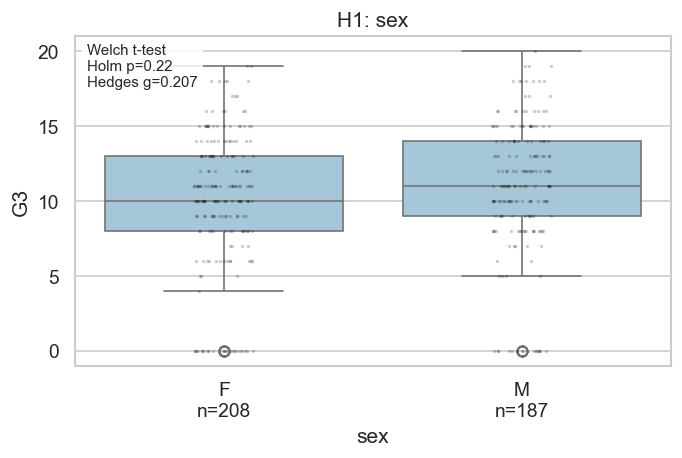

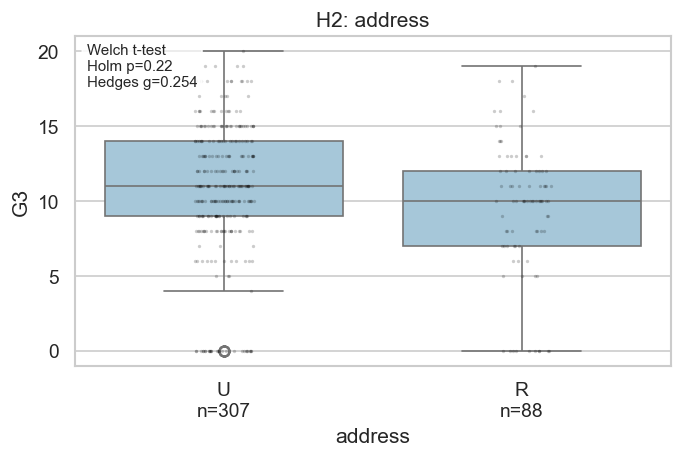

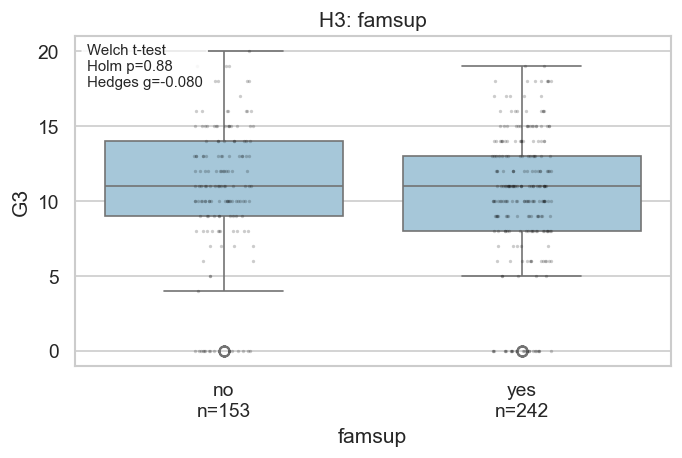

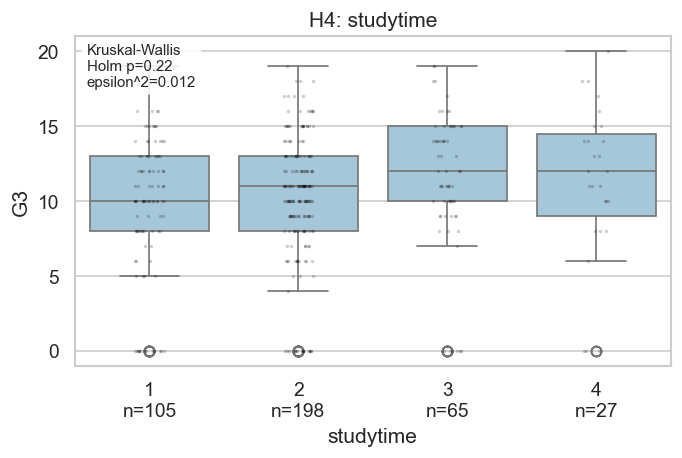

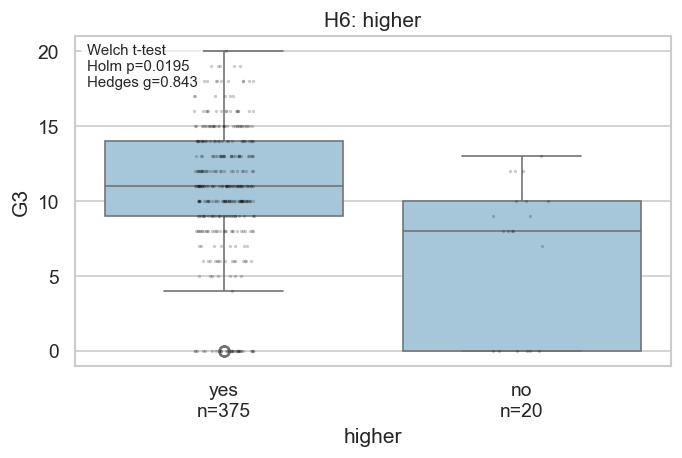

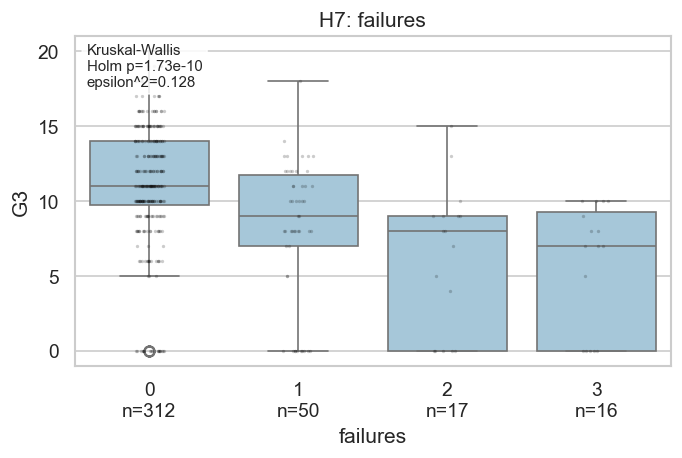

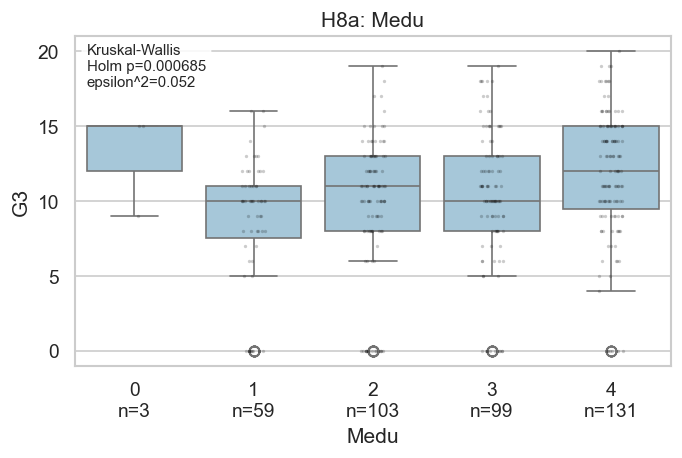

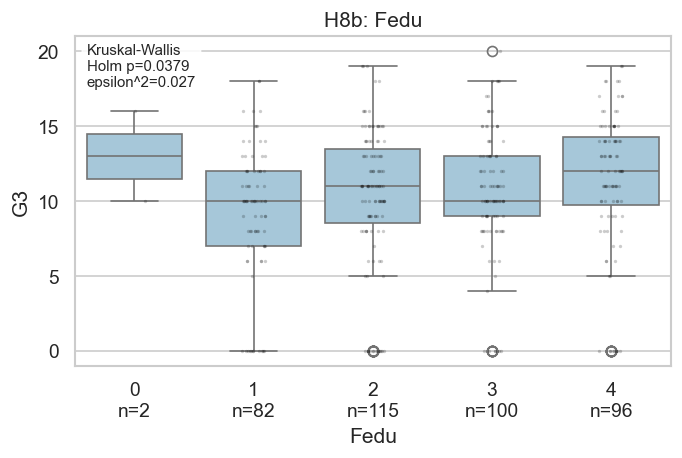

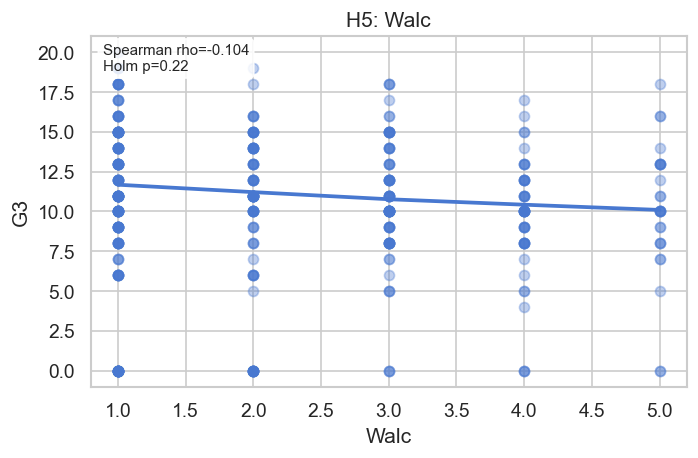

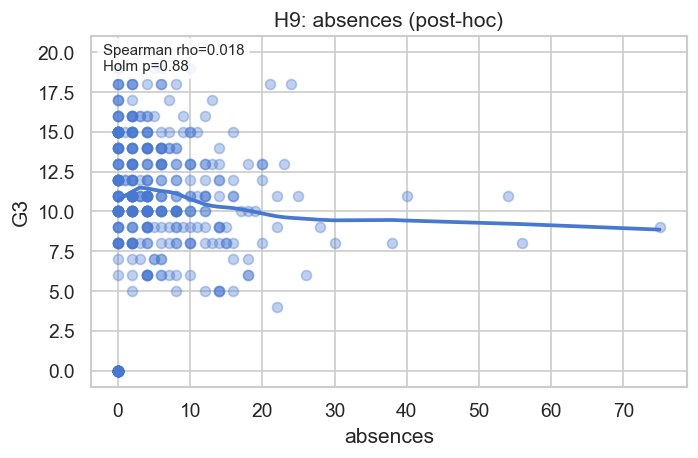

Đã xuất 10 figures hyp_*.png


In [5]:
plot_specs = [
    ("sex", "hyp_h1_sex_g3.png", "H1: sex"), ("address", "hyp_h2_address_g3.png", "H2: address"),
    ("famsup", "hyp_h3_famsup_g3.png", "H3: famsup"), ("studytime", "hyp_h4_studytime_g3.png", "H4: studytime"),
    ("higher", "hyp_h6_higher_g3.png", "H6: higher"), ("failures", "hyp_h7_failures_g3.png", "H7: failures"),
    ("Medu", "hyp_h8a_medu_g3.png", "H8a: Medu"), ("Fedu", "hyp_h8b_fedu_g3.png", "H8b: Fedu"),
]
for var, filename, key in plot_specs:
    row = summary.loc[summary["hypothesis"] == key].iloc[0]
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.boxplot(data=df, x=var, y="G3", ax=ax, color="#9ecae1")
    sns.stripplot(data=df, x=var, y="G3", ax=ax, color="black", alpha=.2, size=2)
    counts = df[var].value_counts().sort_index()
    ax.set_xticklabels([tick.get_text() + chr(10) + f"n={counts.get(type(counts.index[0])(tick.get_text()), counts.get(tick.get_text(), ''))}"
                        for tick in ax.get_xticklabels()])
    annotate(ax, f"{row['test']}" + chr(10) + f"Holm p={row['p_holm']:.3g}" + chr(10) +
             f"{row['effect']}={row['effect_value']:.3f}")
    ax.set_title(key); fig.tight_layout(); fig.savefig(FIGURES_DIR / filename); plt.show()

for var, filename, key in [("Walc", "hyp_h5_walc_g3.png", "H5: Walc"),
                           ("absences", "hyp_h9_absences_g3.png", "H9: absences")]:
    row = summary.loc[summary["hypothesis"] == key].iloc[0]
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.regplot(data=df, x=var, y="G3", lowess=True, scatter_kws={"alpha": .35}, ax=ax)
    annotate(ax, f"Spearman rho={row['effect_value']:.3f}" + chr(10) + f"Holm p={row['p_holm']:.3g}")
    ax.set_title(key + (" (post-hoc)" if var == "absences" else ""))
    fig.tight_layout(); fig.savefig(FIGURES_DIR / filename); plt.show()
print("Đã xuất 10 figures hyp_*.png")

## Kết luận Phase 2

- Kết luận chính dựa trên p-value đã hiệu chỉnh Holm, không dựa trên p-value thô.
- Welch t-test ước lượng khác biệt trung bình và không giả định phương sai bằng nhau; Levene được báo cáo như diagnostic.
- Với biến nhiều mức, Kruskal-Wallis chỉ là omnibus test; bảng Dunn-Holm xác định cặp nhóm khác nhau.
- Dấu effect size luôn theo contrast ghi trong bảng, ví dụ `yes - no` hoặc `U - R`.
- Kết quả chỉ mô tả association trong dữ liệu quan sát. H9 vẫn được ghi rõ là exploratory.